<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
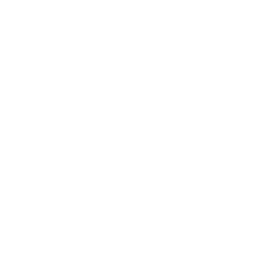
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">平均値分析による外れ値校のフラグ付け</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 教育 / パフォーマンス分析 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

ある地域の教育当局は、地区内のどの学校が学区平均から真に際立った数学の
成績を出しているのか——単に順位で最上位や最下位というだけでなく、標本
変動だけでは説明できないほど際立っている学校はどこか——を知りたいと
考えています。平均値分析（ANOM）はまさにその問いに答えます。各グループ
の平均を全体平均と比較し、上下の判定限界を引いて、その範囲外に平均が
外れた学校をフラグ付けします。

このノートブックでは、バランスの取れた8校のコホート（各校12人、計96
レコード）を構築し、`ALPHA=0.05` の XCHART を用いて **PROC ANOM** を実行
し、フラグ付けされた学校を **PROC UNIVARIATE** に渡して正規性を確認します。
ANOM は全体平均 **499.08** に対して **3** 校をフラグ付けします。**SCH-02**
（平均 532.58）と **SCH-07**（平均 529.17）は上側判定限界 **517.93** を
上回り、**SCH-05**（平均 460.75）は下側限界 **480.23** を下回ります。残る
5校は限界内に収まり、統計的に学区平均と区別できません。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------:|
| WORK.SCHOOL_SCORES | 児童単位の数学テストスコア、8校 | 96 |

コホートは合成データですが現実的です。各校は12人の児童が在籍し、その
スコアは学区目標の500付近（SD 22）を中心とする正規分布から抽出されて
います。3校には意図的なシフトが与えられており——2校は上方向、1校は
下方向——分析が検出すべき本物のシグナルが存在します。

---

In [1]:
/* --------------------------------------------------------
   Generate a balanced 8-school cohort, 12 pupils each (96
   records, within the 100-observation cap). Schools 2 and
   7 are shifted up; school 5 is shifted down, so ANOM has
   real out-of-limit signals to detect.
   -------------------------------------------------------- */
データ work.school_scores;
    呼出 streaminit(2026);
    繰返 school = 1 から 8;
        school_name = cat('SCH-', PUT(school, z2.));
        shift = 0;
        もし school = 2 なら shift = 34;
        もし school = 5 なら shift = -38;
        もし school = 7 なら shift = 30;
        繰返 pupil = 1 から 12;
            math_score = round(rand('normal', 500 + shift, 22), 1);
            出力;
        終了;
    終了;
    保持 school_name math_score;
実行;


NOTE: DATA work.school_scores


NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### 学校ごとのベースライン

ANOM を実行する前に、各学校の数学スコアを要約します。平均はおよそ461
から533の範囲にありますが、生の平均だけでは、どの差が本物でどの差が
標本ノイズなのかを判断できません——それを次に判定限界が決定します。

In [2]:
/* --------------------------------------------------------
   Per-school summary of math scores
   -------------------------------------------------------- */
処理 平均 データ=work.school_scores n mean std MIN MAX maxdec=1;
    分類 school_name;
    変数 math_score;
    見出 school_name='学校' math_score='数学得点';
    表題 '学校別数学得点サマリー';
実行;

                                                      学校別数学得点サマリー                                                       

                                                  The MEANS Procedure

                                      Analysis Variable : math_score 数学得点

        学校                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        SCH-01               12          499.6           26.7          464.0          554.0
        SCH-02               12          532.6           27.7          491.0          579.0
        SCH-03               12          485.8           18.1          461.0          513.0
        SCH-04               12          490.0           23.4          441.0          519.0
        SCH-05               12          460.8           20.9          441.0          514.0
        SCH-06               12          497.9           20.8          465.0          52


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### 平均値分析

PROC ANOM は各学校の平均を全体平均と比較し、`ALPHA=0.05` で上側（UDL）
と下側（LDL）の判定限界を計算します。学校がフラグ付けされるのは、その
平均が限界を越えた場合のみです——管理図と同じ考え方ですが、ファミリー
ワイズ誤り率を5%に保ちながら、グループ平均を同時に比較します。XCHART
は各学校の平均をそれらの限界に対してプロットし、フラグ付けされた学校が
強調表示されます。

                                                      学校別数学得点サマリー                                                       


                    The ANOM Procedure
                    Analysis of Means for 数学得点

  Alpha:            0.0500
  Number of groups: 8
  Grand mean:       499.083333
  MSE:              624.159091

  Group                N       Mean        UDL        LDL     Flag
  -----------------------------------------------------------------
  SCH-01              12   499.5833   517.8623   480.3044         
  SCH-02              12   532.5833   517.8623   480.3044    ABOVE
  SCH-03              12   485.8333   517.8623   480.3044         
  SCH-04              12   490.0000   517.8623   480.3044         
  SCH-05              12   460.7500   517.8623   480.3044    BELOW
  SCH-06              12   497.9167   517.8623   480.3044         
  SCH-07              12   529.1667   517.8623   480.3044    ABOVE
  SCH-08              12   496.8333   517.8623   480.3044         





NOTE: PROC ANOM data=work.school_scores

NOTE: ODS plot written: anom_math_score.spec.json
NOTE: PROC ANOM statement used (96 observations read).
NOTE: ANOM decision limits use the exact equicoordinate multivariate t critical value h(alpha; k, nu) for balanced designs and the sample-size-dependent h(alpha; k, n1..nk, nu) for unbalanced designs (Nelson).


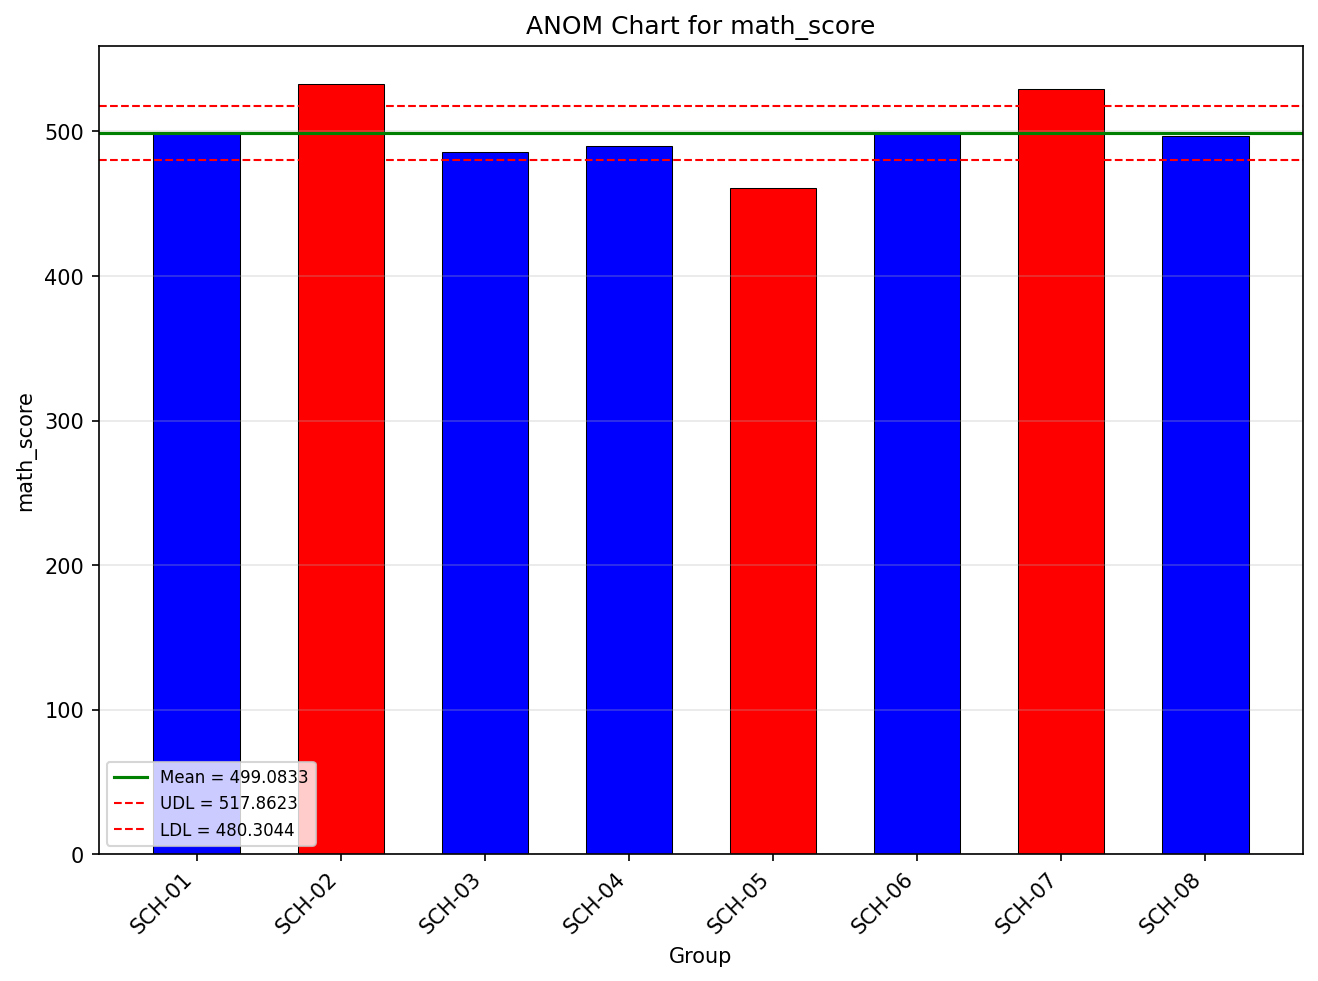

In [3]:
/* --------------------------------------------------------
   PROC ANOM XCHART: test each school mean against the
   grand mean at ALPHA=0.05. OUTTABLE captures the per-school
   means, decision limits, and exceed-limit flags.
   -------------------------------------------------------- */
処理 anom データ=work.school_scores;
    xchart math_score * school_name /
        ALPHA=0.05
        outtable=work.anom_table;
    見出 math_score = '数学得点'
          school_name = '学校';
    表題 'ANOM：学区平均に対する学校の数学成績';
実行;

---

### フラグ付けされた学校の抽出

OUTTABLE データセットは学校ごとに1行を持ち、その平均（`_SUBX_`）、判定
限界（`_LDLX_`、`_UDLX_`）、そして学校が限界外にあるときに `ABOVE` または
`BELOW` に設定される `_EXLIM_` フラグを含みます。フラグ付けされた行を
選択すると、より詳しく調べる価値のある学校が得られます。

In [4]:
/* --------------------------------------------------------
   Keep only schools flagged outside the decision limits
   -------------------------------------------------------- */
データ work.outlier_schools;
    設定 work.anom_table;
    条件 _exlim_ ne ' ';
    保持 school_name _subx_ _exlim_;
実行;

処理 印刷 データ=work.outlier_schools noobs;
    変数 school_name _subx_ _exlim_;
    表題 'ANOM判定限界を外れた学校';
実行;

                                                     ANOM判定限界を外れた学校                                                     

school_name      _SUBX_  _EXLIM_
SCH-02       532.583333  ABOVE
SCH-05           460.75  BELOW
SCH-07       529.166667  ABOVE




NOTE: DATA work.outlier_schools


NOTE: Read 8 rows from work.anom_table.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.outlier_schools

NOTE: PROC PRINT completed: 3 observations printed, 3 variables


---

### フラグ付けされた学校の診断

ANOM の判定限界は、基礎となるスコアがおおよそ正規分布であることを前提
としています。フラグに基づいて行動する前に、PROC UNIVARIATE の
Shapiro-Wilk 検定を用いて、各フラグ付け校でその前提を確認します。

In [5]:
/* --------------------------------------------------------
   Merge the flagged-school list back to pupil scores and
   run distributional diagnostics on each flagged school.
   -------------------------------------------------------- */
処理 並替 データ=work.school_scores; 基準 school_name; 実行;
処理 並替 データ=work.outlier_schools; 基準 school_name; 実行;

データ work.outlier_scores;
    結合 work.school_scores (IN=a)
          work.outlier_schools (IN=b);
    基準 school_name;
    もし a かつ b;
実行;

処理 単変量 データ=work.outlier_scores NORMAL;
    分類 school_name;
    変数 math_score;
    見出 school_name='学校' math_score='数学得点';
    HISTOGRAM math_score / NORMAL;
    表題 '該当校の分布診断';
実行;

                                                        該当校の分布診断                                                        

                        学校=SCH-02

                                                The UNIVARIATE Procedure
                                         Variable:  math_score  (数学得点)

                                                        Moments

N                                 12    Sum Weights                       12
Mean                      532.583333    Sum Observations         6391.000000
Std Deviation              27.655209    Variance                  764.810606
Skewness                    0.074859    Kurtosis                   -0.713041
Uncorrected SS        3412153.000000    Corrected SS             8412.916667
Coeff Variation             5.192654    Std Error Mean              7.983371

          Basic Statistical Measures           

Location              Variability              
--------  ----------  -------------  ----------
Mean      532.583333  Std


NOTE: PROC SORT data=work.school_scores

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 96 rows from work.school_scores.
NOTE: Wrote work.school_scores (96 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.outlier_schools

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.outlier_schools.
NOTE: Wrote work.outlier_schools (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.outlier_scores

NOTE: Stream 1 processed 96 rows, max BY-group size: 12 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.outlier_scores (36 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC UNIVARIATE


---

### 解釈

ANOM の XCHART は、全体平均 **499.08**（UDL **517.93**、LDL **480.23**）
に対して8校のうち **3** 校をフラグ付けします。

- **SCH-02** — 平均 **532.58**、上側判定限界を上回る。
- **SCH-07** — 平均 **529.17**、上側判定限界を上回る。
- **SCH-05** — 平均 **460.75**、下側判定限界を下回る。

他の5校（SCH-01、SCH-03、SCH-04、SCH-06、SCH-08）は限界内に収まって
います。学区平均との差は標本変動だけで生じる範囲内にあり、対応は不要
です。

PROC UNIVARIATE の正規性チェックがフラグを裏付けます。上位2校はきれいに
正規分布に従っており——SCH-02（Shapiro-Wilk W **0.966**、p **0.860**）と
SCH-07（W **0.967**、p **0.883**）——その高い平均は信頼できるシグナルです。
しかし下位校の **SCH-05** は正規性検定に不合格です（W **0.803**、
p **0.010**、歪度 **1.76**）。その分布は右に歪んでおり、ほとんどの児童が
低い一方で数人が学区標準に近い値を示しています。これは有用な留意点です
——SCH-05 の不足は本物ですが、それは一様なシフトではなく、苦戦している
児童の集中したグループによって引き起こされており、全校的なプログラム
よりも的を絞った介入を示唆しています。

ANOM は単純な順位付けではできないことを実現します。学区平均から真に
異なる3校を、そう見えるだけの5校から切り分け、しかもそれを、学区の
指導部が一目で読み取れる1枚のチャートで行います。

---

In [6]:
/* --------------------------------------------------------
   Export the per-school ANOM results (means, decision
   limits, and flags) for district leadership.
   -------------------------------------------------------- */
処理 EXPORT データ=work.anom_table
    OUTFILE='school_anom_results.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.anom_table outfile=school_anom_results.csv

NOTE: Exported 8 rows to school_anom_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 社外秘
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供：<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>